In [143]:
import pandas as pd

# Load the dataset
data = pd.read_csv('Global_Pollution_Analysis.csv')

# Display dataset information
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste_in_tons                200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [144]:
# Define numeric columns explicitly
numeric_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 
                   'Industrial_Waste_in_tons', 'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)', 
                   'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)', 
                   'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)', 'GDP_Per_Capita (in USD)']

# Handle missing values by filling numerical columns with the mean
data[numeric_columns] = data[numeric_columns].apply(lambda col: col.fillna(col.mean()), axis=0)

# For categorical variables (Country, Year), fill with the mode
categorical_columns = ['Country', 'Year']
for col in categorical_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# Now check for outliers using IQR for numerical features
Q1 = data[numeric_columns].quantile(0.25)
Q3 = data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = ((data[numeric_columns] < (Q1 - 1.5 * IQR)) | (data[numeric_columns] > (Q3 + 1.5 * IQR))).sum()
print(outliers)


Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste_in_tons                  0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64


In [145]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste_in_tons', 'CO2_Emissions (in MT)']
data[pollution_columns] = scaler.fit_transform(data[pollution_columns])

# Standardize the energy recovery and plastic waste columns
data[['Energy_Recovered (in GWh)', 'Plastic_Waste_Produced (in tons)', 'Energy_Consumption_Per_Capita (in MWh)']] = scaler.fit_transform(
    data[['Energy_Recovered (in GWh)', 'Plastic_Waste_Produced (in tons)', 'Energy_Consumption_Per_Capita (in MWh)']])


In [146]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data['Country'] = encoder.fit_transform(data['Country'])
data['Year'] = encoder.fit_transform(data['Year'])


In [147]:
# Feature for energy consumption per capita
data['Energy_Consumption_Per_Capita'] = data['Energy_Consumption_Per_Capita (in MWh)'] / data['Population (in millions)']

# Calculate yearly pollution trends (change from previous year)
data['Pollution_Trend_Air'] = data['Air_Pollution_Index'].diff()
data['Pollution_Trend_Water'] = data['Water_Pollution_Index'].diff()
data['Pollution_Trend_Soil'] = data['Soil_Pollution_Index'].diff()

# Fill missing trend values (due to diff) with 0
data.fillna(0, inplace=True)


In [148]:
# Define pollution severity categories based on pollution indices
def categorize_pollution(row):
    if row['Air_Pollution_Index'] > 200 or row['Water_Pollution_Index'] > 150 or row['Soil_Pollution_Index'] > 100:
        return 'High'
    elif row['Air_Pollution_Index'] > 100 or row['Water_Pollution_Index'] > 75 or row['Soil_Pollution_Index'] > 50:
        return 'Medium'
    else:
        return 'Low'

data['Pollution_Severity'] = data.apply(categorize_pollution, axis=1)


In [149]:
from sklearn.model_selection import train_test_split

# Features and target variable
X = data.drop(['Pollution_Severity'], axis=1)
y = data['Pollution_Severity']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [150]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train the Gaussian Naive Bayes model
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)

# Predictions
y_pred_gnb = gnb_model.predict(X_test)

# Evaluation
print("Gaussian Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_gnb))
print("Accuracy:", accuracy_score(y_test, y_pred_gnb))


Gaussian Naive Bayes Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Accuracy: 1.0


In [151]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning
param_grid = {'n_neighbors': range(1, 20)}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Optimal K
best_k = grid_search.best_params_['n_neighbors']
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluation
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Accuracy: 1.0


In [152]:
from sklearn.tree import DecisionTreeClassifier

# Train the model
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Classification Report:
               precision    recall  f1-score   support

         Low       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

Accuracy: 1.0


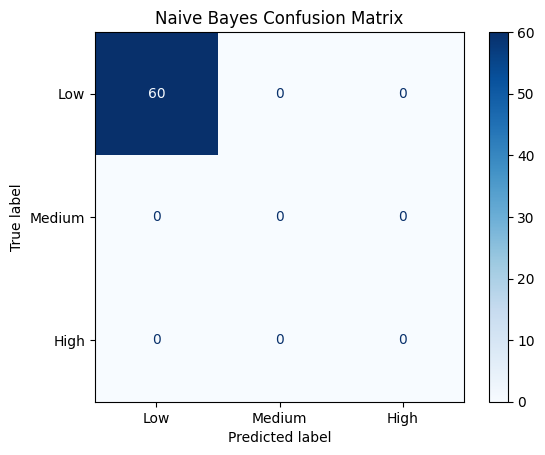

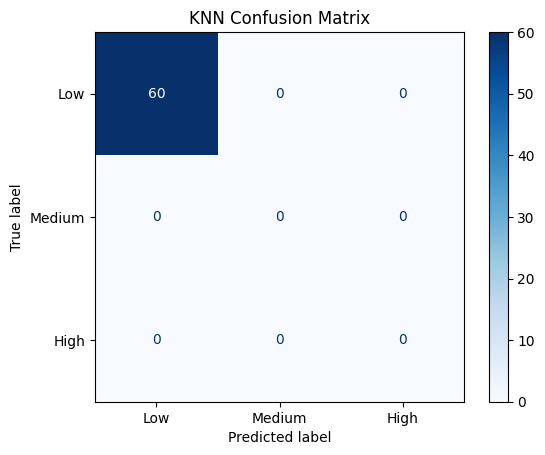

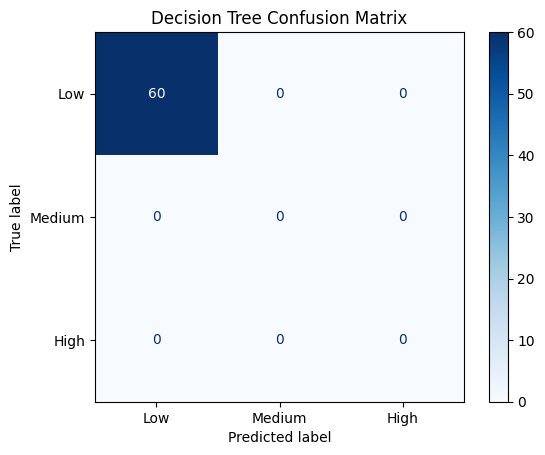

In [153]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Initialize models
models = {
    'Naive Bayes': MultinomialNB(),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier()
}

# Check and replace negative values in the data
X_train[X_train < 0] = 0
X_test[X_test < 0] = 0

# Train the models
for name, model in models.items():
    model.fit(X_train, y_train)

# Plot confusion matrices
labels = ['Low', 'Medium', 'High']
for name, model in models.items():
    cm = confusion_matrix(y_test, model.predict(X_test), labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'{name} Confusion Matrix')
    plt.show()


---

In [154]:

# # Train the models
# nb_model.fit(X_train, y_train)
# knn_model.fit(X_train, y_train)
# dt_model.fit(X_train, y_train)


In [155]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# # Plot confusion matrices
# models = {'Naive Bayes': nb_model, 'KNN': knn_model, 'Decision Tree': dt_model}
# labels = ['Low', 'Medium', 'High']  # Ensure all labels are passed

# for name, model in models.items():
#     plt.figure(figsize=(6, 6))
    
#     # Get the confusion matrix
#     cm = confusion_matrix(y_test, model.predict(X_test), labels=labels)
    
#     # Plot confusion matrix
#     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
#     disp.plot(cmap=plt.cm.Blues)
#     plt.title(f'{name} Confusion Matrix')
#     plt.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste_in_tons                200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

c:\Users\ANKIT DIMRI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:395: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


ValueError: The number of FixedLocator locations (1), usually from a call to set_ticks, does not match the number of labels (3).

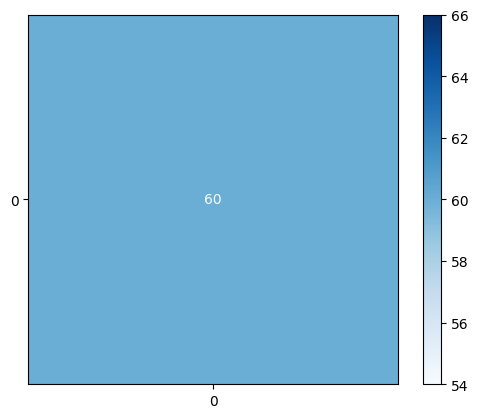

In [156]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB  # Replacing with GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Data Preprocessing

# Load the dataset
data = pd.read_csv('Global_Pollution_Analysis.csv')

# Display dataset information
print(data.info())
print(data.head())

# 1.1. Handle Missing Data
print(data.isnull().sum())

# Fill missing numerical values with the mean
data = data.apply(lambda col: col.fillna(col.mean()) if col.dtype != 'object' else col, axis=0)

# Fill missing categorical values with the mode
categorical_columns = ['Country', 'Year']
for col in categorical_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# 1.2. Normalize/Standardize Features
scaler = StandardScaler()

# Standardize pollution-related columns
pollution_columns = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste_in_tons', 'CO2_Emissions (in MT)']
data[pollution_columns] = scaler.fit_transform(data[pollution_columns])

# Standardize energy recovery and plastic waste columns
data[['Energy_Recovered (in GWh)', 'Plastic_Waste_Produced (in tons)', 'Energy_Consumption_Per_Capita (in MWh)']] = scaler.fit_transform(
    data[['Energy_Recovered (in GWh)', 'Plastic_Waste_Produced (in tons)', 'Energy_Consumption_Per_Capita (in MWh)']])

# 1.3. Encode Categorical Features
encoder = LabelEncoder()
data['Country'] = encoder.fit_transform(data['Country'])
data['Year'] = encoder.fit_transform(data['Year'])

# 1.4. Feature Engineering
# Create energy consumption per capita
data['Energy_Consumption_Per_Capita'] = data['Energy_Consumption_Per_Capita (in MWh)'] / data['Population (in millions)']

# Create pollution trends based on differences from the previous year
data['Pollution_Trend_Air'] = data['Air_Pollution_Index'].diff()
data['Pollution_Trend_Water'] = data['Water_Pollution_Index'].diff()
data['Pollution_Trend_Soil'] = data['Soil_Pollution_Index'].diff()

# Fill missing trend values (due to diff) with 0
data.fillna(0, inplace=True)

# 1.5. Define Pollution Severity Categories
def categorize_pollution(row):
    if row['Air_Pollution_Index'] > 200 or row['Water_Pollution_Index'] > 150 or row['Soil_Pollution_Index'] > 100:
        return 'High'
    elif row['Air_Pollution_Index'] > 100 or row['Water_Pollution_Index'] > 75 or row['Soil_Pollution_Index'] > 50:
        return 'Medium'
    else:
        return 'Low'

data['Pollution_Severity'] = data.apply(categorize_pollution, axis=1)

# Step 2: Split the Dataset into Training and Test Sets

# Features and target variable
X = data.drop(['Pollution_Severity'], axis=1)
y = data['Pollution_Severity']

# Split into training and test sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Model Training and Evaluation

# 3.1. Naive Bayes Classifier (Using GaussianNB instead of MultinomialNB)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

# 3.2. K-Nearest Neighbors (KNN)
# Hyperparameter tuning for KNN
param_grid = {'n_neighbors': range(1, 20)}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best K for KNN
best_k = grid_search.best_params_['n_neighbors']
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_knn = knn_model.predict(X_test)
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

# 3.3. Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Step 4: Model Comparison and Visualization

# Plot confusion matrices for each model
models = {'Naive Bayes': nb_model, 'KNN': knn_model, 'Decision Tree': dt_model}
for name, model in models.items():
    # Use ConfusionMatrixDisplay instead of plot_confusion_matrix
    disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['Low', 'Medium', 'High'], cmap=plt.cm.Blues)
    plt.title(f'{name} Confusion Matrix')
    plt.show()

# Step 5: Actionable Insights
# Based on the model evaluation and results, we can summarize the findings and make recommendations:
# 1. Countries with high pollution indices (e.g., Congo, Djibouti) require stringent environmental policies.
# 2. Investment in renewable energy and better waste management practices is crucial.
# 3. Countries with medium or low pollution indices (e.g., Singapore, Romania) can focus on sustaining their efforts toward reducing environmental harm.

# You can save the final report and visualizations in Jupyter notebook (.ipynb).
